<a href="https://colab.research.google.com/github/Karthik5412/Deep-Learning-Projects/blob/main/CNN/birds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!kaggle datasets download -d veeralakrishna/200-bird-species-with-11788-images

Dataset URL: https://www.kaggle.com/datasets/veeralakrishna/200-bird-species-with-11788-images
License(s): CC0-1.0
200-bird-species-with-11788-images.zip: Skipping, found more recently modified local copy (use --force to force download)


In [49]:
import zipfile

zip = zipfile.ZipFile('/content/200-bird-species-with-11788-images.zip', 'r')
zip.extractall('/content')
zip.close()

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
# Extract the first file (CUB_200_2011) into a specific directory
!mkdir -p bird_dataset_1
!tar -xvzf /content/CUB_200_2011.tgz -C ./bird_dataset_1

# Extract the second file (segmentations) into a specific directory
!mkdir -p bird_dataset_2
!tar -xvzf /content/segmentations.tgz -C ./bird_dataset_2

Streaming output truncated to the last 5000 lines.
segmentations/198.Rock_Wren/Rock_Wren_0125_188951.png
segmentations/198.Rock_Wren/Rock_Wren_0122_189042.png
segmentations/198.Rock_Wren/Rock_Wren_0033_189397.png
segmentations/198.Rock_Wren/Rock_Wren_0066_189034.png
segmentations/198.Rock_Wren/Rock_Wren_0114_189283.png
segmentations/198.Rock_Wren/Rock_Wren_0076_189141.png
segmentations/198.Rock_Wren/Rock_Wren_0113_189204.png
segmentations/198.Rock_Wren/Rock_Wren_0024_188942.png
segmentations/198.Rock_Wren/Rock_Wren_0069_188969.png
segmentations/198.Rock_Wren/Rock_Wren_0025_188897.png
segmentations/198.Rock_Wren/Rock_Wren_0026_189181.png
segmentations/198.Rock_Wren/Rock_Wren_0062_189045.png
segmentations/198.Rock_Wren/Rock_Wren_0109_189094.png
segmentations/198.Rock_Wren/Rock_Wren_0053_189112.png
segmentations/198.Rock_Wren/Rock_Wren_0044_189127.png
segmentations/198.Rock_Wren/Rock_Wren_0116_189101.png
segmentations/198.Rock_Wren/Rock_Wren_0111_189443.png
segmentations/198.Rock_Wren/Roc

In [52]:
from tensorflow import  keras
from keras.utils import image_dataset_from_directory

In [53]:
dir = '/content/bird_dataset_2/segmentations'
batch = 64

In [54]:
train_ds = image_dataset_from_directory(directory= dir, labels= 'inferred',seed=123, subset='training', validation_split=0.2,image_size= (224,224), label_mode= 'int', batch_size= batch, color_mode='rgb')

val_ds = image_dataset_from_directory(directory= dir, labels= 'inferred', label_mode= 'int',seed=123, subset='validation', validation_split=0.2, image_size= (224,224), batch_size= batch, color_mode='rgb')

Found 11788 files belonging to 200 classes.
Using 9431 files for training.
Found 11788 files belonging to 200 classes.
Using 2357 files for validation.


In [55]:
bird_names = train_ds.class_names
print(bird_names)

['001.Black_footed_Albatross', '002.Laysan_Albatross', '003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet', '007.Parakeet_Auklet', '008.Rhinoceros_Auklet', '009.Brewer_Blackbird', '010.Red_winged_Blackbird', '011.Rusty_Blackbird', '012.Yellow_headed_Blackbird', '013.Bobolink', '014.Indigo_Bunting', '015.Lazuli_Bunting', '016.Painted_Bunting', '017.Cardinal', '018.Spotted_Catbird', '019.Gray_Catbird', '020.Yellow_breasted_Chat', '021.Eastern_Towhee', '022.Chuck_will_Widow', '023.Brandt_Cormorant', '024.Red_faced_Cormorant', '025.Pelagic_Cormorant', '026.Bronzed_Cowbird', '027.Shiny_Cowbird', '028.Brown_Creeper', '029.American_Crow', '030.Fish_Crow', '031.Black_billed_Cuckoo', '032.Mangrove_Cuckoo', '033.Yellow_billed_Cuckoo', '034.Gray_crowned_Rosy_Finch', '035.Purple_Finch', '036.Northern_Flicker', '037.Acadian_Flycatcher', '038.Great_Crested_Flycatcher', '039.Least_Flycatcher', '040.Olive_sided_Flycatcher', '041.Scissor_tailed_Flycatcher', '042.Ver

In [56]:
import re

def processing_birds(bird):
    new = re.sub(r'[^a-zA-Z]+', ' ', bird)

    return new.strip()


birds =[]
for bird in bird_names :
    birds.append(processing_birds(bird))

birds

['Black footed Albatross',
 'Laysan Albatross',
 'Sooty Albatross',
 'Groove billed Ani',
 'Crested Auklet',
 'Least Auklet',
 'Parakeet Auklet',
 'Rhinoceros Auklet',
 'Brewer Blackbird',
 'Red winged Blackbird',
 'Rusty Blackbird',
 'Yellow headed Blackbird',
 'Bobolink',
 'Indigo Bunting',
 'Lazuli Bunting',
 'Painted Bunting',
 'Cardinal',
 'Spotted Catbird',
 'Gray Catbird',
 'Yellow breasted Chat',
 'Eastern Towhee',
 'Chuck will Widow',
 'Brandt Cormorant',
 'Red faced Cormorant',
 'Pelagic Cormorant',
 'Bronzed Cowbird',
 'Shiny Cowbird',
 'Brown Creeper',
 'American Crow',
 'Fish Crow',
 'Black billed Cuckoo',
 'Mangrove Cuckoo',
 'Yellow billed Cuckoo',
 'Gray crowned Rosy Finch',
 'Purple Finch',
 'Northern Flicker',
 'Acadian Flycatcher',
 'Great Crested Flycatcher',
 'Least Flycatcher',
 'Olive sided Flycatcher',
 'Scissor tailed Flycatcher',
 'Vermilion Flycatcher',
 'Yellow bellied Flycatcher',
 'Frigatebird',
 'Northern Fulmar',
 'Gadwall',
 'American Goldfinch',
 'Euro

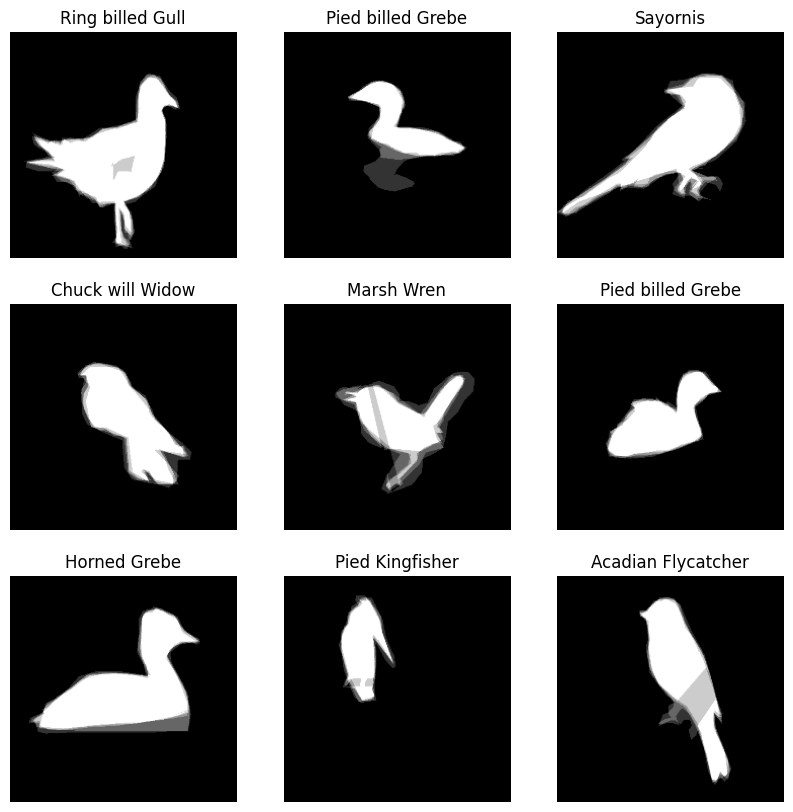

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize= (10,10))
for image , labels in train_ds.take(1):
    for i in range(9) :
        plt.subplot(3,3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(birds[labels[i]])
        plt.axis('off')

In [58]:
import tensorflow as tf

def scale(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(scale)
val_ds = val_ds.map(scale)

In [59]:
import pandas as pd
import numpy as np

In [60]:
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras import Sequential

In [61]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3),padding='valid', activation='relu',input_shape=(224,224,3)),
    MaxPool2D(pool_size=(3,3),strides=2),
    Conv2D(64, kernel_size=(3,3),padding='valid', activation='relu'),
    MaxPool2D(pool_size=(3,3),strides=2),
    Conv2D(128, kernel_size=(3,3),padding='valid', activation='relu'),
    MaxPool2D(pool_size=(3,3),strides=2),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(1,activation='softmax')
])

In [62]:
cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    10,240,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,341,697 (39.45 MB)

 Trainable params: 10,341,697 (39.45 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [64]:
history = cnn.fit(train_ds,validation_data=val_ds, epochs= 5, validation_split=0.2, batch_size=32,verbose=1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


148/148 ━━━━━━━━━━━━━━━━━━━━ 38s 176ms/step - accuracy: 0.0047 - loss: nan - val_accuracy: 0.0068 - val_loss: nan
Epoch 2/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.0047 - loss: nan - val_accuracy: 0.0068 - val_loss: nan
Epoch 3/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.0047 - loss: nan - val_accuracy: 0.0068 - val_loss: nan
Epoch 4/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - accuracy: 0.0047 - loss: nan - val_accuracy: 0.0068 - val_loss: nan
Epoch 5/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.0047 - loss: nan - val_accuracy: 0.0068 - val_loss: nan
